In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[  0.33961949,  -1.92319724],
       [  2.07523919,  -0.97984088],
       [ -7.03669833,  -8.78371532],
       ...,
       [ -9.32428797, -11.35985659],
       [ 10.05734553,  -0.07388563],
       [  0.24530927,  -2.58094969]])

In [5]:
y

array([1, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 1, 2,
       0, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 0, 2, 0, 1, 2, 2, 1, 1, 0, 0, 1,
       2, 1, 0, 2, 1, 0, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1,
       1, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 2, 0, 1, 2,
       0, 2, 2, 1, 2, 0, 2, 0, 1, 0, 0, 2, 2, 2, 1, 0, 1, 1, 2, 2, 1, 1,
       2, 0, 1, 2, 0, 0, 2, 1, 2, 1, 0, 1, 2, 1, 1, 2, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 2, 2, 0, 0, 1, 2, 1, 2, 0, 2, 1, 1, 1, 1, 0, 1,
       2, 1, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2,
       2, 2, 1, 1, 2, 0, 2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1,
       0, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 1, 2, 0, 2, 1, 1,
       1, 0, 1, 2, 0, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0, 1, 2, 1, 0, 1, 1, 2,
       1, 0, 1, 2, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0,
       0, 0, 0, 2, 2, 2, 1, 0, 1, 1, 0, 2, 1, 0, 0, 0, 0, 2, 0, 0, 2, 2,
       0, 2, 2, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2,

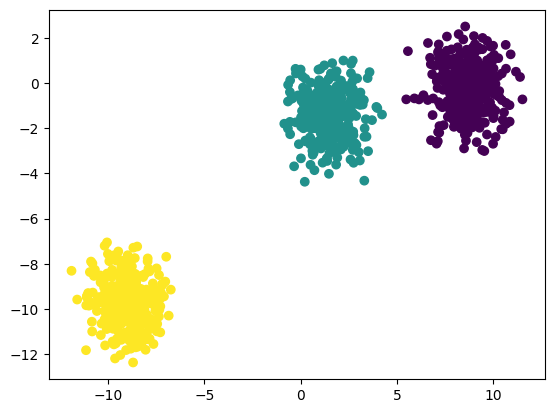

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [12]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [13]:
wcss

[1340.0000000000007,
 168.5956775893056,
 49.13057087942087,
 41.651937511192955,
 32.76558224138557,
 25.24307757543892,
 22.97077036904127,
 20.52238995870812,
 18.14205103300101,
 16.766146857389305]

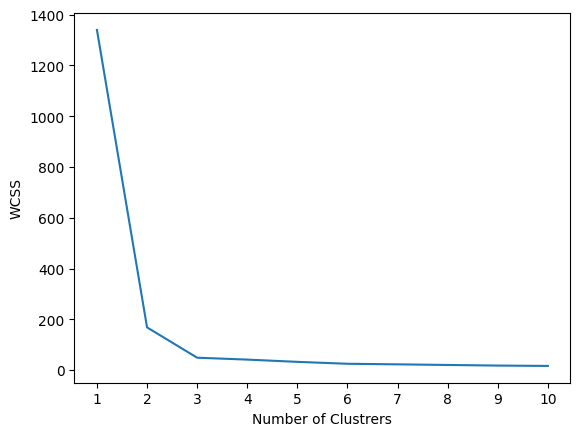

In [14]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
kmeans.fit_predict(X_train_scaled)

array([2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 0, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1, 1,
       2, 2, 2, 2, 0, 1, 0, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 2, 1, 0, 1, 2,
       0, 0, 0, 2, 1, 2, 1, 0, 2, 1, 2, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 1,
       0, 2, 1, 0, 2, 1, 2, 2, 1, 1, 0, 2, 2, 0, 2, 1, 1, 1, 1, 1, 0, 1,
       2, 2, 1, 1, 1, 1, 1, 2, 0, 0, 2, 2, 0, 2, 1, 2, 1, 1, 0, 1, 1, 2,
       0, 1, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 2, 2, 2, 0, 0, 0, 1, 0, 2, 0,
       0, 0, 0, 2, 1, 1, 0, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2,
       2, 2, 1, 2, 2, 0, 0, 1, 1, 0, 1, 2, 1, 2, 2, 0, 2, 0, 2, 2, 0, 2,
       0, 0, 2, 1, 1, 0, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 2, 0, 2, 1, 1, 1,
       2, 1, 0, 1, 2, 0, 1, 0, 2, 2, 0, 2, 0, 1, 0, 0, 2, 1, 2, 1, 0, 1,
       0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 2, 2, 0, 1, 1, 1, 2, 0, 1, 0, 2, 2,
       2, 2, 1, 0, 2, 2, 0, 2, 0, 1, 0, 2, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2,
       1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 2, 1, 2, 2, 0,
       2, 1, 0, 2, 1, 1, 2, 0, 0, 0, 2, 1, 0, 2, 2,

In [17]:
y_pred=kmeans.predict(X_test_scaled)

In [18]:
y_pred

array([0, 1, 1, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 2, 0, 2, 0, 1,
       2, 1, 0, 2, 0, 2, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 1, 1, 2, 0, 2,
       2, 1, 1, 0, 2, 0, 1, 1, 2, 1, 0, 2, 2, 2, 1, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 1, 0, 0, 2, 0, 2, 2, 0, 1, 0,
       1, 2, 2, 0, 0, 2, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 2, 2, 2, 2,
       1, 2, 1, 0, 2, 1, 1, 0, 1, 2, 2, 0, 0, 1, 2, 1, 0, 2, 1, 1, 2, 1,
       1, 2, 0, 2, 1, 0, 2, 2, 0, 1, 0, 0, 1, 1, 1, 2, 0, 2, 2, 0, 1, 1,
       0, 2, 1, 2, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 2, 0, 2, 0, 0,
       0, 1, 0, 1, 0, 1, 2, 2, 0, 2, 2, 1, 2, 2, 2, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 2, 0, 0, 2, 1, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0, 0, 2, 1, 2,
       0, 0, 0, 1, 1, 0, 2, 1, 2, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1, 1, 0, 1,
       1, 0, 2, 2, 2, 2, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 2, 0, 1, 1,
       2, 0, 1, 2, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2, 0,
       1, 2, 0, 2, 0, 0, 1, 0, 1, 2, 2, 1, 1, 2, 1,

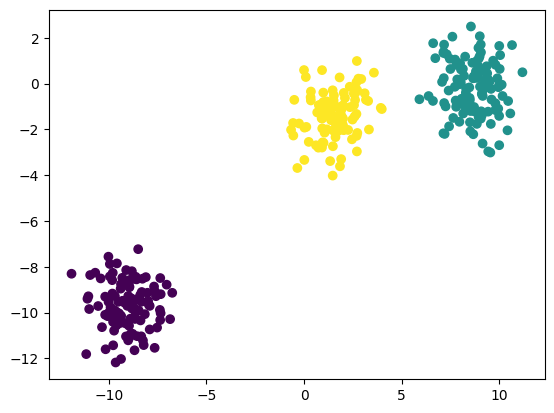

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [20]:
!pip install kneed

In [21]:
from kneed import KneeLocator

In [22]:
from sklearn.metrics import silhouette_score

In [23]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [24]:
silhouette_coefficients

[np.float64(0.788658488407444),
 np.float64(0.7432349022803059),
 np.float64(0.5907303514382809),
 np.float64(0.49668710170940916),
 np.float64(0.40502645445836594),
 np.float64(0.5087558159263018),
 np.float64(0.37353442209438537),
 np.float64(0.334160998623334),
 np.float64(0.35084760512623087)]

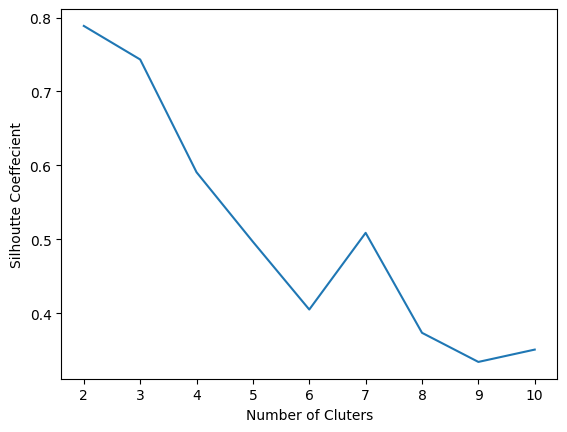

In [25]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()